In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, r2_score, confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score
)
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

In [3]:
mat = pd.read_csv('student-mat.csv', sep=';')
por = pd.read_csv('student-por.csv', sep=';')

In [4]:
df = pd.concat([mat.assign(subject='math'), por.assign(subject='por')],
               ignore_index=True)

print("Shape:", df.shape)
df.head()

Shape: (1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math


In [5]:
print(df.info())
print(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [6]:
df['pass_fail'] = (df['G3'] >= 10).astype(int)


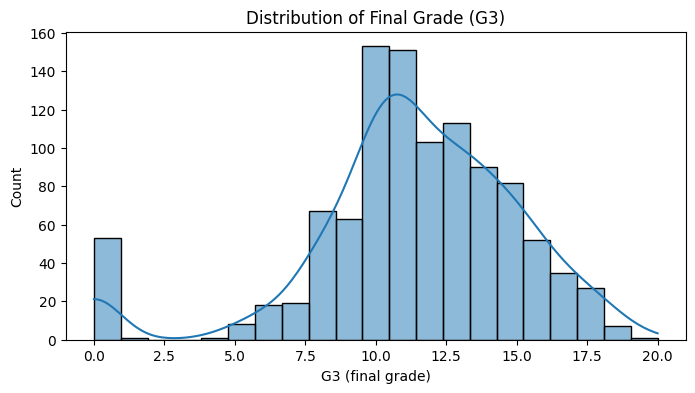

In [7]:
plt.figure(figsize=(8,4))
sns.histplot(df['G3'], bins=21, kde=True)
plt.title('Distribution of Final Grade (G3)')
plt.xlabel('G3 (final grade)')
plt.ylabel('Count')
plt.show()

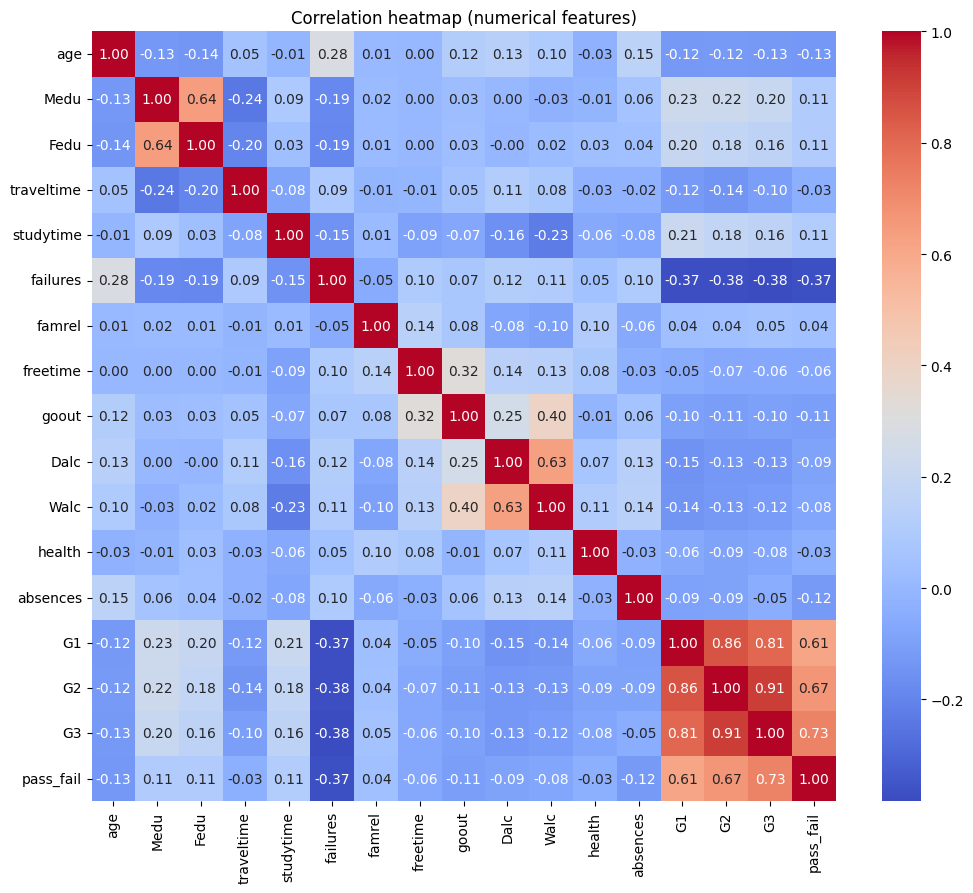

In [8]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation heatmap (numerical features)')
plt.show()

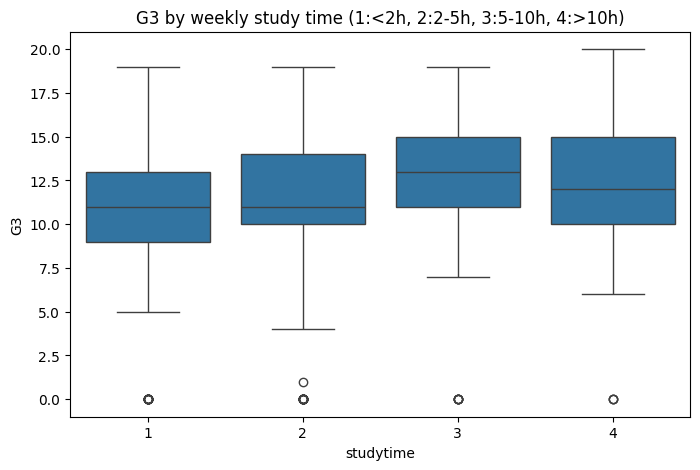

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='studytime', y='G3', data=df)
plt.title('G3 by weekly study time (1:<2h, 2:2-5h, 3:5-10h, 4:>10h)')
plt.show()

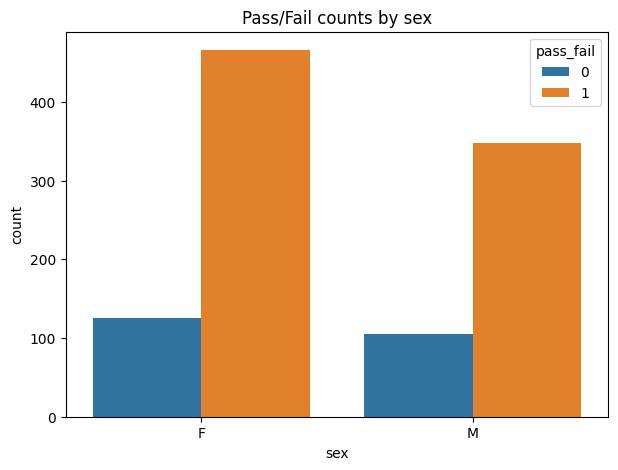

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(x='sex', hue='pass_fail', data=df)
plt.title('Pass/Fail counts by sex')
plt.show()

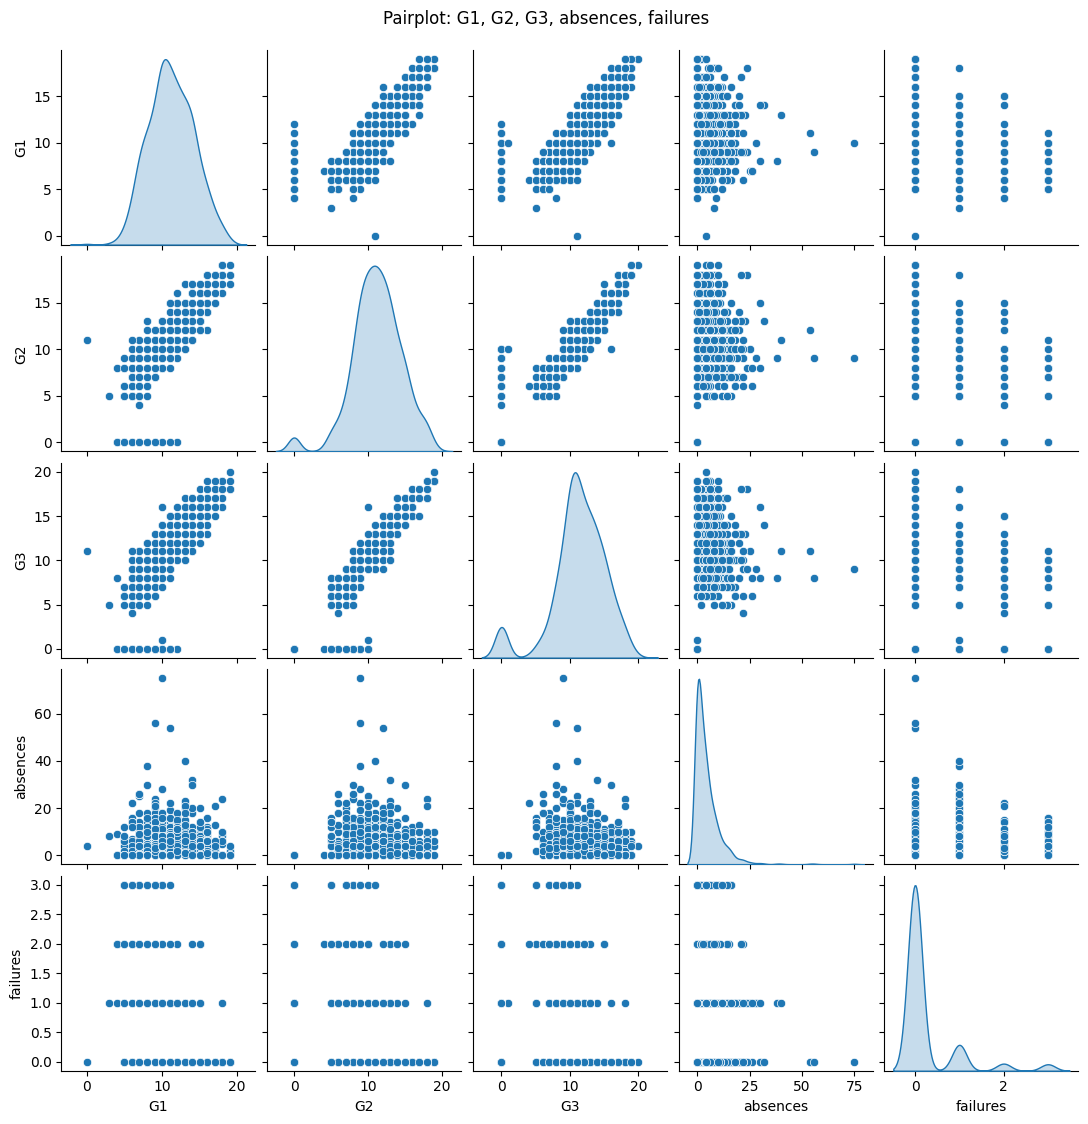

In [11]:
sample_cols = ['G1','G2','G3','absences','failures']
sns.pairplot(df[sample_cols], diag_kind='kde', height=2.2)
plt.suptitle('Pairplot: G1, G2, G3, absences, failures', y=1.02)
plt.show()

In [12]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
subject       0
pass_fail     0
dtype: int64


In [13]:
X = df.drop(columns=['G3','pass_fail'])   # for baseline regression, we will re-add variants
y_reg = df['G3']
y_clf = df['pass_fail']

In [14]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical cols:", cat_cols)
print("Numerical cols:", num_cols[:10], "...")

Categorical cols: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']
Numerical cols: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc'] ...


In [16]:
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [17]:
X_processed = preprocessor.fit_transform(X)
print("Processed feature shape:", X_processed.shape)


Processed feature shape: (1044, 60)


In [19]:
X_trainval, X_test, y_trainval_reg, y_test_reg, y_trainval_clf, y_test_clf = train_test_split(
    X_processed, y_reg, y_clf, test_size=0.15, random_state=42, stratify=y_clf)

X_train, X_val, y_train_reg, y_val_reg, y_train_clf, y_val_clf = train_test_split(
    X_trainval, y_trainval_reg, y_trainval_clf, test_size=0.1765, random_state=42, stratify=y_trainval_clf)
print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

Train/Val/Test sizes: 730 157 157


In [20]:
def build_regression_model(input_dim, lr=0.001, hidden_units=[128,64], dropout=0.2):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for u in hidden_units:
        model.add(layers.Dense(u, activation='relu'))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='linear'))
    model.compile(optimizer=optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return model

def build_classification_model(input_dim, lr=0.001, hidden_units=[128,64], dropout=0.2):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for u in hidden_units:
        model.add(layers.Dense(u, activation='relu'))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

input_dim = X_train.shape[1]

In [21]:
reg_model = build_regression_model(input_dim, lr=0.001, hidden_units=[128,64], dropout=0.3)
es = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
hist_reg = reg_model.fit(X_train, y_train_reg, validation_data=(X_val, y_val_reg),
                        epochs=120, batch_size=32, callbacks=[es], verbose=2)

Epoch 1/120
23/23 - 2s - 94ms/step - loss: 81.3903 - mae: 8.2465 - val_loss: 22.5098 - val_mae: 4.1706
Epoch 2/120
23/23 - 0s - 6ms/step - loss: 16.8575 - mae: 3.0855 - val_loss: 5.9441 - val_mae: 1.6232
Epoch 3/120
23/23 - 0s - 6ms/step - loss: 11.7450 - mae: 2.6140 - val_loss: 3.9843 - val_mae: 1.4755
Epoch 4/120
23/23 - 0s - 7ms/step - loss: 8.6994 - mae: 2.2666 - val_loss: 3.0905 - val_mae: 1.2088
Epoch 5/120
23/23 - 0s - 6ms/step - loss: 7.8936 - mae: 2.1236 - val_loss: 3.2119 - val_mae: 1.3317
Epoch 6/120
23/23 - 0s - 6ms/step - loss: 7.4541 - mae: 2.1124 - val_loss: 2.6573 - val_mae: 1.1191
Epoch 7/120
23/23 - 0s - 6ms/step - loss: 6.8943 - mae: 1.9967 - val_loss: 2.7443 - val_mae: 1.1964
Epoch 8/120
23/23 - 0s - 6ms/step - loss: 6.9217 - mae: 2.0426 - val_loss: 2.6999 - val_mae: 1.1869
Epoch 9/120
23/23 - 0s - 6ms/step - loss: 6.6887 - mae: 2.0273 - val_loss: 2.6247 - val_mae: 1.1516
Epoch 10/120
23/23 - 0s - 6ms/step - loss: 6.1868 - mae: 1.8979 - val_loss: 2.5579 - val_mae: 1

In [22]:
y_pred_test = reg_model.predict(X_test).flatten()
mse = mean_squared_error(y_test_reg, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_test)
print(f"Regression test RMSE: {rmse:.3f}, R2: {r2:.3f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Regression test RMSE: 1.574, R2: 0.832


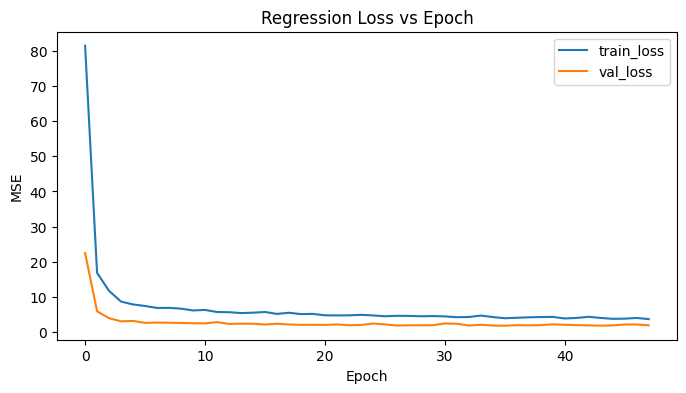

In [23]:
plt.figure(figsize=(8,4))
plt.plot(hist_reg.history['loss'], label='train_loss')
plt.plot(hist_reg.history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Regression Loss vs Epoch'); plt.legend()
plt.show()

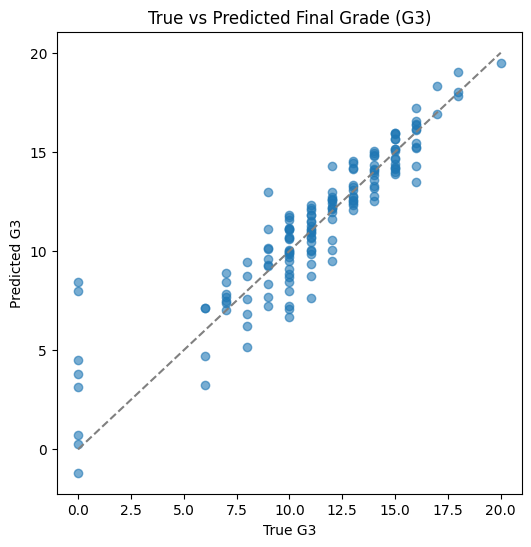

In [24]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_test, alpha=0.6)
plt.plot([0,20],[0,20], '--', color='gray')
plt.xlabel('True G3'); plt.ylabel('Predicted G3')
plt.title('True vs Predicted Final Grade (G3)')
plt.show()


In [25]:
clf_model = build_classification_model(input_dim, lr=0.001, hidden_units=[128,64], dropout=0.3)
es2 = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
hist_clf = clf_model.fit(X_train, y_train_clf, validation_data=(X_val, y_val_clf),
                        epochs=80, batch_size=32, callbacks=[es2], verbose=2)

Epoch 1/80
23/23 - 2s - 87ms/step - accuracy: 0.7411 - loss: 0.5547 - val_accuracy: 0.8344 - val_loss: 0.3527
Epoch 2/80
23/23 - 0s - 6ms/step - accuracy: 0.8260 - loss: 0.3931 - val_accuracy: 0.9108 - val_loss: 0.2545
Epoch 3/80
23/23 - 0s - 6ms/step - accuracy: 0.8753 - loss: 0.3087 - val_accuracy: 0.9108 - val_loss: 0.1952
Epoch 4/80
23/23 - 0s - 7ms/step - accuracy: 0.8836 - loss: 0.2646 - val_accuracy: 0.9236 - val_loss: 0.1664
Epoch 5/80
23/23 - 0s - 7ms/step - accuracy: 0.8959 - loss: 0.2390 - val_accuracy: 0.9363 - val_loss: 0.1506
Epoch 6/80
23/23 - 0s - 6ms/step - accuracy: 0.8918 - loss: 0.2157 - val_accuracy: 0.9490 - val_loss: 0.1416
Epoch 7/80
23/23 - 0s - 7ms/step - accuracy: 0.9219 - loss: 0.1955 - val_accuracy: 0.9490 - val_loss: 0.1386
Epoch 8/80
23/23 - 0s - 6ms/step - accuracy: 0.9041 - loss: 0.2257 - val_accuracy: 0.9490 - val_loss: 0.1378
Epoch 9/80
23/23 - 0s - 6ms/step - accuracy: 0.9151 - loss: 0.1787 - val_accuracy: 0.9427 - val_loss: 0.1423
Epoch 10/80
23/23 

In [26]:
y_pred_proba = clf_model.predict(X_test).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)
acc = accuracy_score(y_test_clf, y_pred)
print("Classification test accuracy:", acc)
print("Classification report:\n", classification_report(y_test_clf, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Classification test accuracy: 0.910828025477707
Classification report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        35
           1       0.94      0.94      0.94       122

    accuracy                           0.91       157
   macro avg       0.87      0.87      0.87       157
weighted avg       0.91      0.91      0.91       157



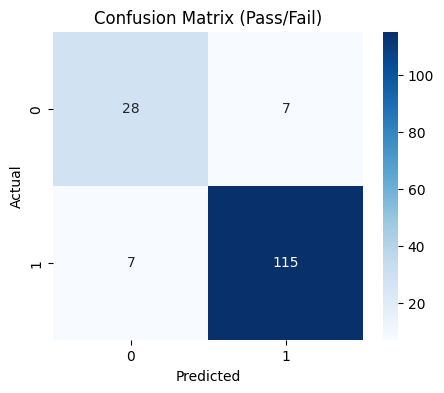

In [27]:
cm = confusion_matrix(y_test_clf, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (Pass/Fail)')
plt.show()

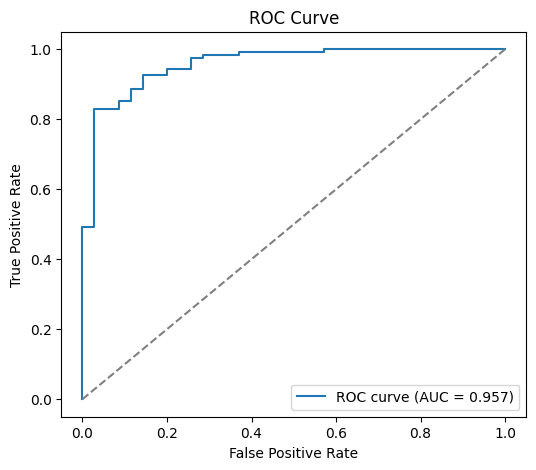

In [28]:
fpr, tpr, _ = roc_curve(y_test_clf, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve')
plt.legend()
plt.show()

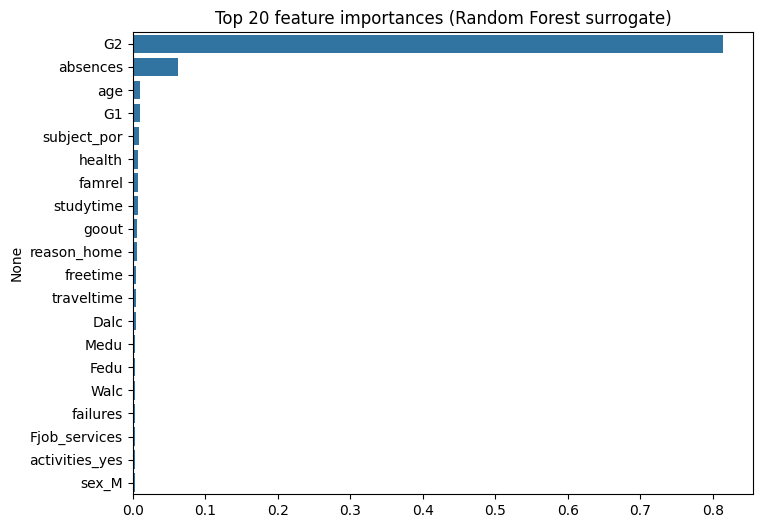

In [29]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
# Use original X (not the one-hot) by performing simple get_dummies to inspect features
X_orig = pd.get_dummies(df.drop(columns=['G3','pass_fail']), drop_first=True)
rf.fit(X_orig, df['G3'])
feat_imp = pd.Series(rf.feature_importances_, index=X_orig.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Top 20 feature importances (Random Forest surrogate)')
plt.show()

In [30]:
reg_model.save('mlp_reg_model.h5')
clf_model.save('mlp_clf_model.h5')

In [31]:
preds_df = pd.DataFrame({'true_G3': y_test_reg, 'pred_G3': y_pred_test})
preds_df.to_csv('g3_predictions.csv', index=False)
print("Saved models and predictions.")


Saved models and predictions.
